Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



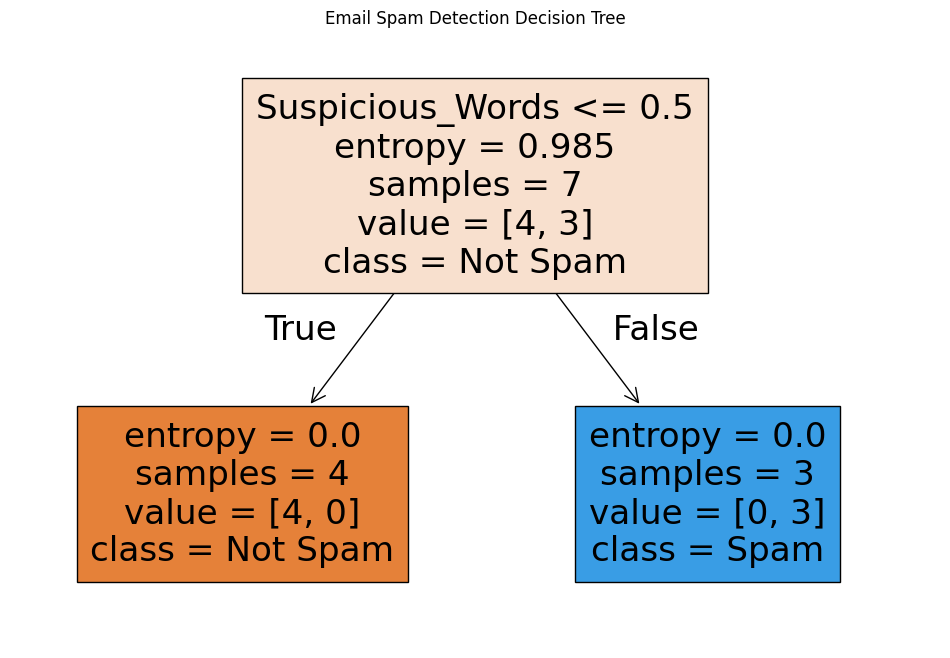

In [1]:
# Email Spam Detection using Decision Tree

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Sample Dataset
data = {
    'Sender_Known': ['Yes','No','No','Yes','No','Yes','No','Yes','No','Yes'],
    'Suspicious_Words': ['No','Yes','Yes','No','Yes','No','Yes','No','Yes','No'],
    'Links': ['Low','High','High','Low','High','Low','High','Low','High','Low'],
    'Attachment': ['No','Yes','No','No','Yes','No','Yes','No','Yes','No'],
    'Subject': ['Normal','Promotional','Promotional','Normal','Promotional','Normal','Promotional','Normal','Promotional','Normal'],
    'Class': ['Not Spam','Spam','Spam','Not Spam','Spam','Not Spam','Spam','Not Spam','Spam','Not Spam']
}

df = pd.DataFrame(data)

# Encode categorical values
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Decision Tree
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Spam','Spam'],
    filled=True
)
plt.title("Email Spam Detection Decision Tree")
plt.show()